# Channel Operators

<font size=4 color="#EBB483">Functions for manipulating Image channels.

In [6]:
import cv_depot.api as cvd

In [2]:
src = '/home/ubuntu/images/misc/p-ring_s-rndr001_d-demo_v001_f0300.exr'
image = cvd.Image.read(src)

<font size=4 color="#EBB483"><br>**remap** combines multiple channels from different images into a single image.
</font>
<font size=4 color="#EBB483">The dictionary provided to **ChannelMap** is of the general signature:
</font>
```python
    { "target-layer.channel": "source-index.layer.channel" }
```


In [16]:
rgb = image[:, :, 'rgb']
normal = image[:, :, 'normal']
ao = image[:, :, 'ao']

cmap = cvd.ChannelMap({
    'beauty.r': '0.r',
    'beauty.g': '0.g',
    'beauty.b': '0.b',
    'norm.0': '1.normal.x',
    'norm.1': '1.normal.y',
    'norm.2': '1.normal.z',
    'ambient_occlusion.i': '2.ao.red',
    'ambient_occlusion.j': '2.ao.green',
    'ambient_occlusion.k': '2.ao.blue',
})
cmap

order    target                    source
-----------------------------------------
0        beauty.r             <--  0.r
1        beauty.g             <--  0.g
2        beauty.b             <--  0.b
3        norm.0               <--  1.normal.x
4        norm.1               <--  1.normal.y
5        norm.2               <--  1.normal.z
6        ambient_occlusion.i  <--  2.ao.red
7        ambient_occlusion.j  <--  2.ao.green
8        ambient_occlusion.k  <--  2.ao.blue

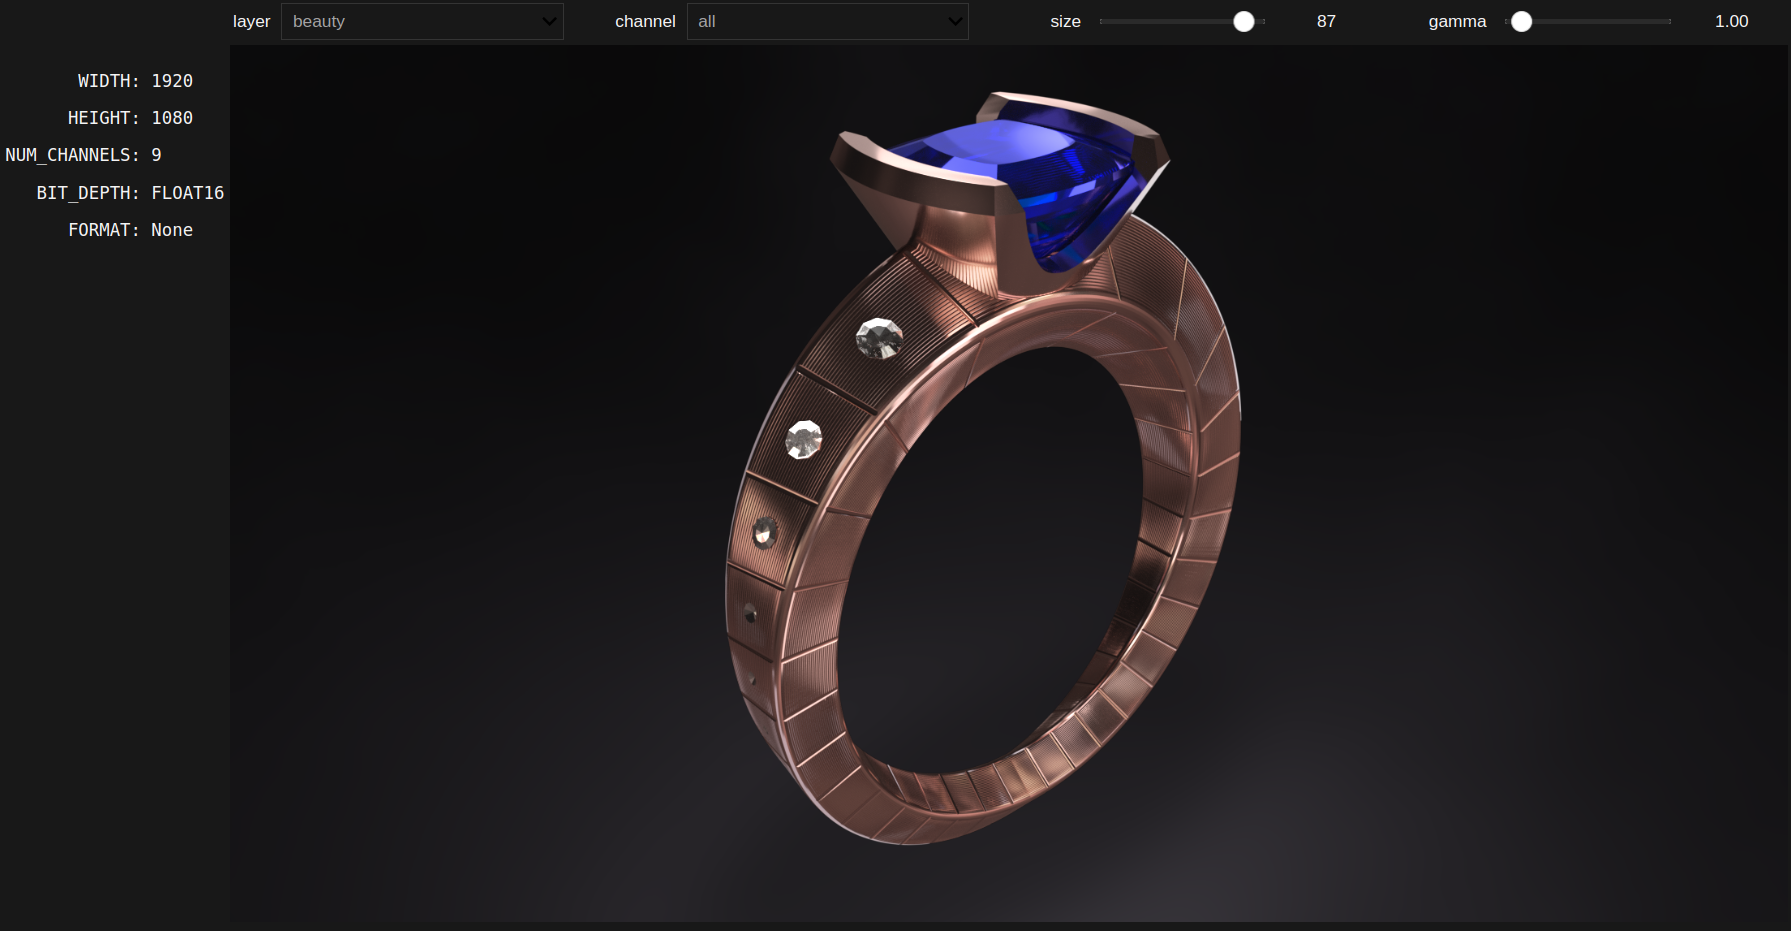

In [29]:
combo = cvd.ops.channel.remap([rgb, normal, ao], cmap)
combo

<font size=4 color="#EBB483"><br>**remap_single_channel** maps a single channel to multiple channels within the same image.

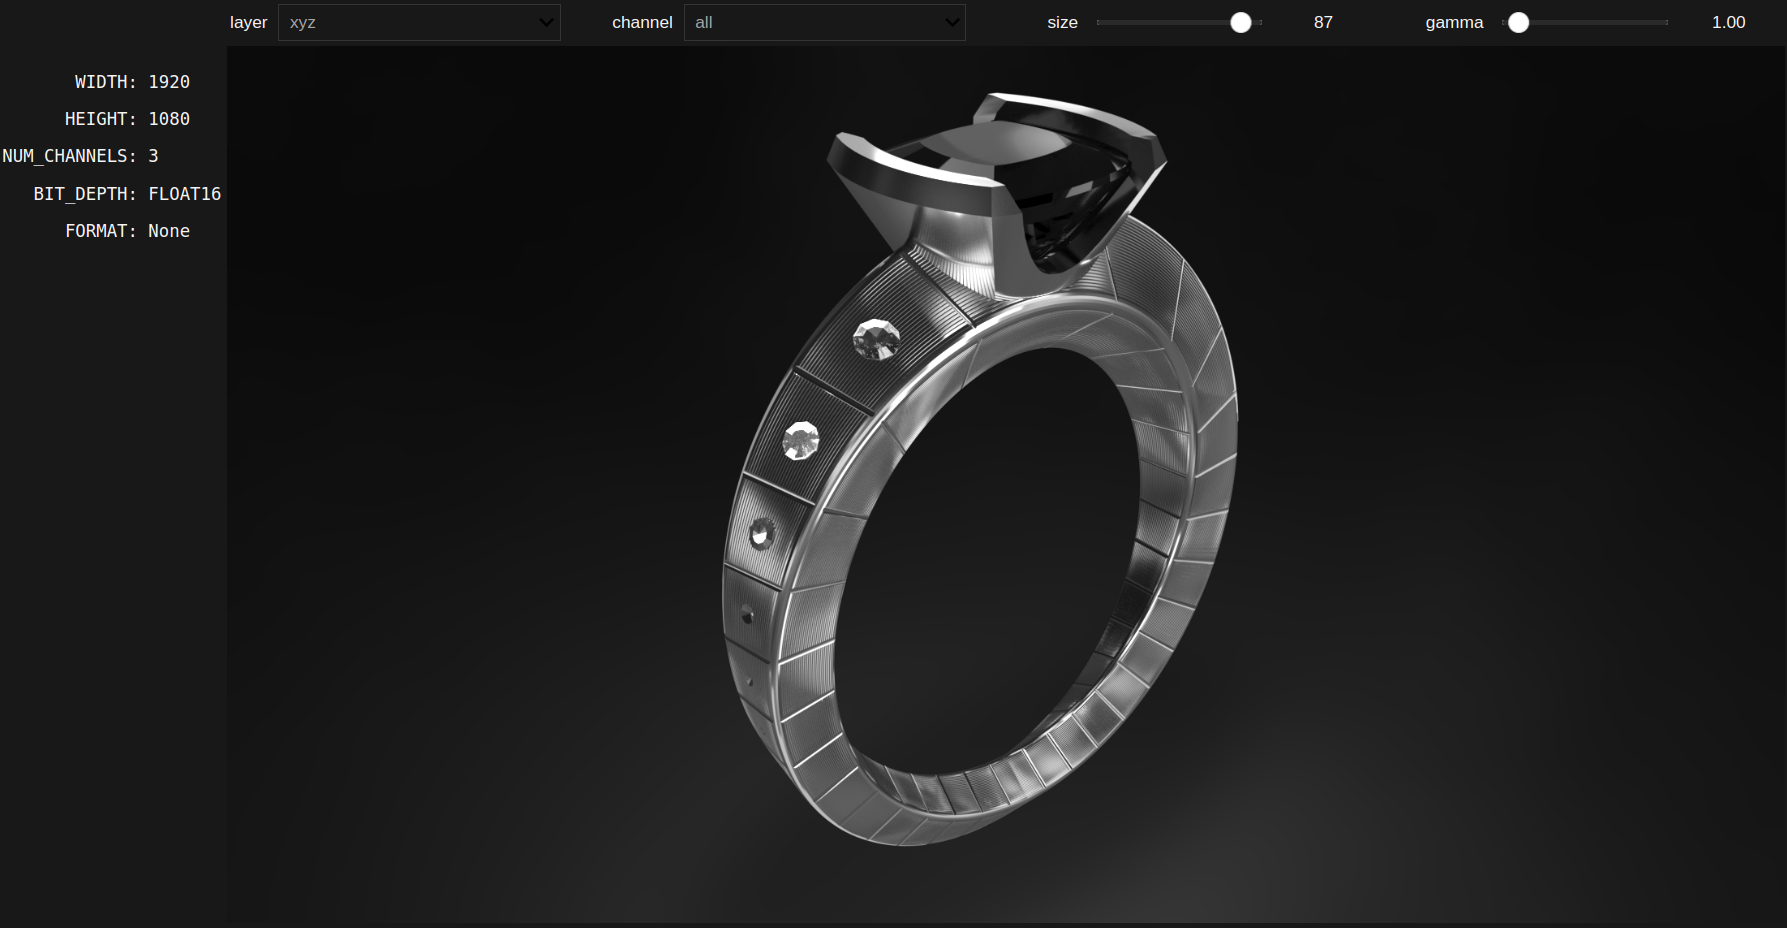

In [30]:
r = image[:, :, 'r']
cvd.ops.channel.remap_single_channel(r, list('xyz'))

<font size=4 color="#EBB483"><br>**mix** combines Image A and Image B by a given amount.

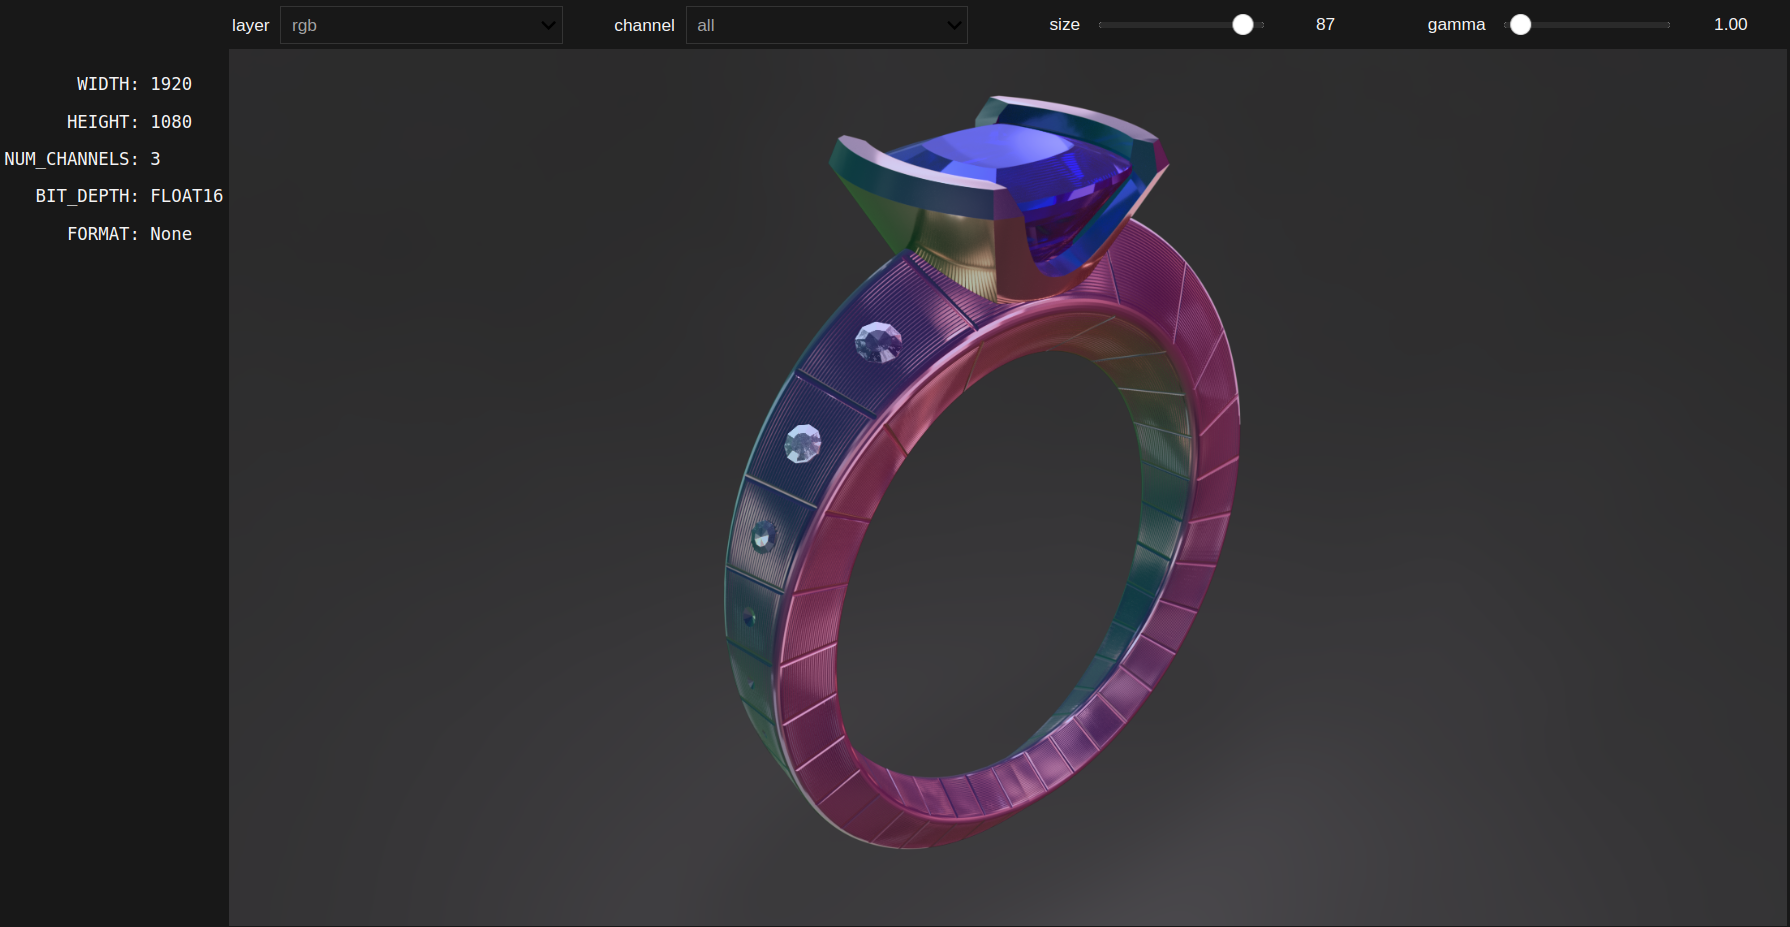

In [31]:
rgb = image[:, :, 'rgb']
norm = image[:, :, 'normal']
cvd.ops.channel.mix(rgb, norm, amount=0.8)

<font size=4 color="#EBB483"><br>to_hsv

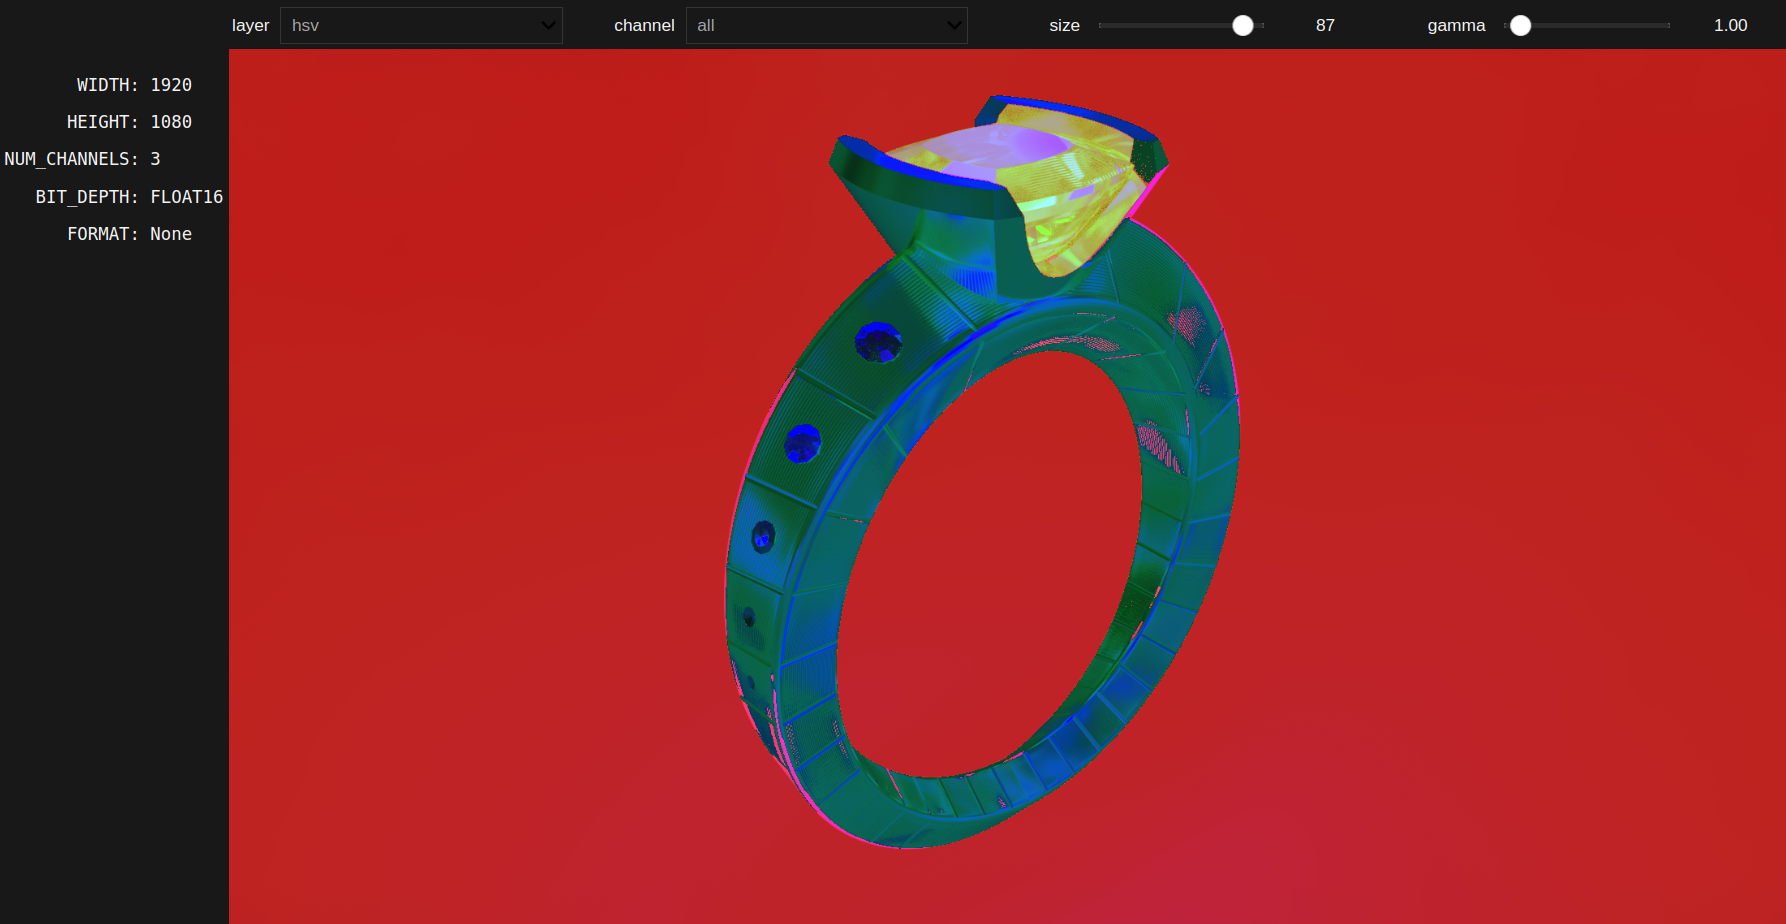

In [32]:
cvd.ops.channel.to_hsv(image)

<font size=4 color="#EBB483"><br>**has_super_brights** determines if any channel has a value above perfect white (1 for float, 255 for int).

<font size=4 color="#EBB483">In this case *position* has values below 0 and above 1.

In [4]:
cvd.ops.channel.has_super_brights(image)

True

<font size=4 color="#EBB483"><br>**has_super_darks** determines if any channel has a value below perfect black (ie 0).

In [5]:
cvd.ops.channel.has_super_darks(image)

True